# **Introduction to Medical Imaging**

In [ ]:
!pip install pydicom nibabel opencv-python matplotlib scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.3 MB/s eta 0:00:00


# **How to work with medical data?**

🖼️ Step 1: Load and Display a Medical Image

(np.float64(-0.5), np.float64(629.5), np.float64(628.5), np.float64(-0.5))

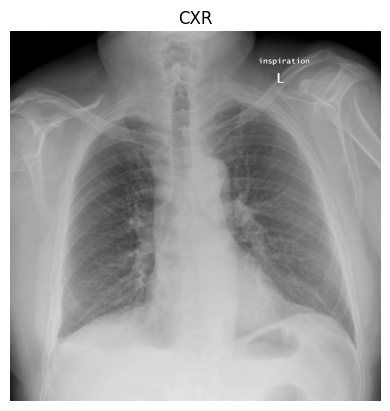

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load image (replace with your image path)
image_cxr = cv2.imread('/content/592662924e9c085eaa08e8bb6accae256d99f2fa4104616cfe257b1e86be5267_big_gallery.jpeg.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(image_cxr, cmap='gray')
plt.title("CXR")
plt.axis('off')


(240, 240, 155)


(np.float64(-0.5), np.float64(239.5), np.float64(239.5), np.float64(-0.5))

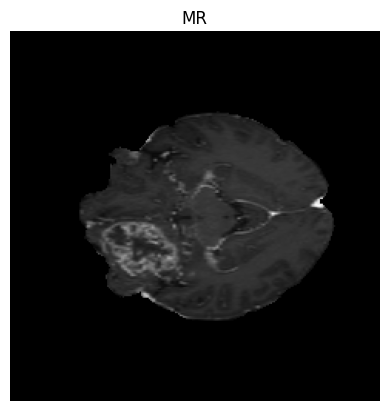

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt

# Load image (replace with your image path)
image = nib.load('/content/BraTS-GLI-00000-000_0000.nii.gz').get_fdata()
print(image.shape)

plt.imshow(image[:, :, 60], cmap='gray')
plt.title("MR")
plt.axis('off')


🧠 Step 2: Basic Image Processing

Image Normalization

(np.float64(-0.5), np.float64(629.5), np.float64(628.5), np.float64(-0.5))

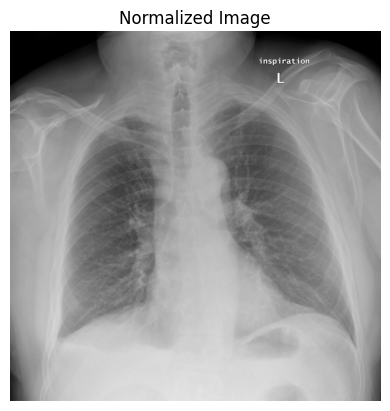

In [ ]:
import numpy as np

image = image_cxr
normalized = (image-np.mean(image)) / (np.max(image)-np.min(image))

plt.imshow(normalized, cmap='gray')
plt.title("Normalized Image")
plt.axis('off')


Edge Detection (Canny)

(np.float64(-0.5), np.float64(629.5), np.float64(628.5), np.float64(-0.5))

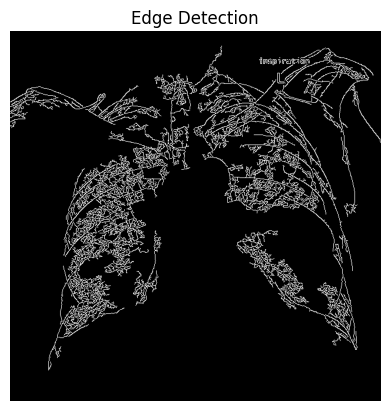

In [ ]:
gray_img = image_cxr.astype(np.uint8)
edges = cv2.Canny(gray_img, 10, 150)

plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")
plt.axis('off')


# **Basics of Pathology Informatics**

📦 Step 1: Install Required Libraries (Colab)

In [ ]:
!apt-get install openslide-tools
!pip install openslide-python matplotlib pillow

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libopenslide0
Suggested packages:
  libtiff-tools
The following NEW packages will be installed:
  libopenslide0 openslide-tools
0 upgraded, 2 newly installed, 0 to remove and 1 not upgraded.
Need to get 104 kB of archives.
After this operation, 297 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libopenslide0 amd64 3.4.1+dfsg-5build1 [89.8 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 openslide-tools amd64 3.4.1+dfsg-5build1 [13.8 kB]
Fetched 104 kB in 2s (67.9 kB/s)
Selecting previously unselected package libopenslide0.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../libopenslide0_3.4.1+dfsg-5build1_amd64.deb ...
Unpacking libopenslide0 (3.4.1+dfsg-5build1) ...
Selecting previously unselected package openslide-tools.

🧠 Step 2: Load the SVS Image

In [ ]:
import openslide

slide = openslide.OpenSlide('/content/TCGA-A6-2686-01Z-00-DX1.0540a027-2a0c-46c7-9af0-7b8672631de7.svs')

print("Slide dimensions:", slide.dimensions)
print("Number of levels:", slide.level_count)
print("Downsample factors:", slide.level_downsamples)


Slide dimensions: (125661, 61796)
Number of levels: 4
Downsample factors: (1.0, 4.000015915963711, 16.001345575546207, 32.004729059321946)


🖼️ Step 3: Visualize a Thumbnail (Recommended First)

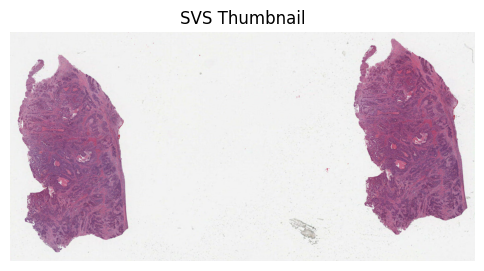

In [ ]:
import matplotlib.pyplot as plt

thumbnail = slide.get_thumbnail((1024, 1024))

plt.figure(figsize=(6,6))
plt.imshow(thumbnail)
plt.axis('off')
plt.title("SVS Thumbnail")
plt.show()


🧭 Step 4: Work with Different Resolution *Levels*

In [ ]:
level = 0
dims = slide.level_dimensions[level]

region_low = slide.read_region(
    (0, 0),
    level=level,
    size=dims
)

plt.figure(figsize=(6,6))
plt.imshow(region_low)
plt.axis('off')
plt.title(f"Level {level} View")
plt.show()

**📚 Popular Public Medical Datasets**

You can use these in Colab:

*   Chest X-ray (Pneumonia)
*   Brain MRI (Tumor)
*   COVID-19 CT scans
*   NIH ChestXray14
